# CA1 — Neural Networks Basics: Implementations

This notebook implements the core code for the assignment, organized into clear sections:
- Credit Card Fraud Detection (EDA, preprocessing, MLP + Logistic Regression, evaluation)
- Concrete Strength Regression (preprocessing, model comparisons)
- Adaline on Iris (from-scratch linear unit)
- MNIST Autoencoders + Classifiers (pretraining + frozen encoders)

Run sections independently; some require datasets or long training.

In [7]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

try:
    from scikeras.wrappers import KerasClassifier
    HAS_SCIKERAS = True
except Exception:
    HAS_SCIKERAS = False

np.random.seed(42)
tf.random.set_seed(42)

print("Environment ready. TensorFlow:", tf.__version__)

Environment ready. TensorFlow: 2.19.0


## Q1 — McCulloch–Pitts Neuron: Logic, Parity, Majority
- Deterministic threshold units compute boolean functions using fixed weights and a threshold.
- We demonstrate AND/OR/NOT with a single neuron, XOR via a 2-layer composition, and 3-input Majority.

In [11]:
import itertools
import numpy as np
import pandas as pd

def H(u):
    u = np.asarray(u)
    return (u >= 0).astype(int)

def mcp_unit(x, w, theta):
    x = np.asarray(x)
    return H(np.dot(w, x) - theta)

def gate_and(a, b):
    return mcp_unit([a, b], np.array([1.0, 1.0]), 1.5)

def gate_or(a, b):
    return mcp_unit([a, b], np.array([1.0, 1.0]), 0.5)

def gate_not(a):
    return H(-1.0 * a + 0.5)

rows = []
for a, b in itertools.product([0,1],[0,1]):
    rows.append({"A":a, "B":b, "AND":int(gate_and(a,b)), "OR":int(gate_or(a,b)), "NOT A":int(gate_not(a))})
pd.DataFrame(rows)

,A,B,AND,OR,NOT A
0,0,0,0,0,1
1,0,1,0,1,1
2,1,0,0,1,0
3,1,1,1,1,0


### Parity (XOR) and Majority
- XOR is not linearly separable but can be composed from threshold gates: XOR = (A OR B) AND NOT(A AND B).
- Majority for 3 inputs fires if at least two inputs are 1.

#### Theoretical Notes (Q1)
- XOR non-linear separability: points (01,10) vs (00,11) cannot be separated by a single hyperplane in $\mathbb{R}^2$, hence a single threshold neuron cannot compute XOR.
- Two-layer construction:
$$
(A \oplus B) = (A \lor B) \land \neg(A \land B).
$$
Each gate is a McCulloch–Pitts unit; stacking them yields XOR.
- Majority of 3: let $s = A + B + C$. A single threshold neuron
$$
y = H\big([1,1,1]^\top [A,B,C] - \theta\big),\quad \theta = 1.5,
$$
fires iff $s \ge 2$, which is majority voting.

In [12]:
def gate_xor(a, b):
    and_ab = gate_and(a, b)
    or_ab = gate_or(a, b)
    nand_part = gate_not(and_ab)
    return gate_and(or_ab, nand_part)

def majority3(a, b, c):
    s = a + b + c
    return H(s - 1.5)

rows = []
for a, b in itertools.product([0,1],[0,1]):
    rows.append({"A":a, "B":b, "XOR":int(gate_xor(a,b))})
xor_tbl = pd.DataFrame(rows)

rows = []
for a, b, c in itertools.product([0,1],[0,1],[0,1]):
    rows.append({"A":a, "B":b, "C":c, "MAJ":int(majority3(a,b,c))})
maj_tbl = pd.DataFrame(rows)

xor_tbl, maj_tbl

(   A  B  XOR
 0  0  0    0
 1  0  1    1
 2  1  0    1
 3  1  1    0,
    A  B  C  MAJ
 0  0  0  0    0
 1  0  0  1    0
 2  0  1  0    0
 3  0  1  1    1
 4  1  0  0    0
 5  1  0  1    1
 6  1  1  0    1
 7  1  1  1    1)

## Q2 — Adaline and Madaline
This section covers Adaline on Breast Cancer and a Madaline (Rule II–style) classifier on Moons/Circles.

### 2.1 Adaline — From SSE to LMS (Theory)
We minimize the squared error objective:
$$
J(\mathbf{w}, b) \,=\, \tfrac{1}{2}\sum_{i=1}^N\Big(t_i - (\mathbf{w}^\top\mathbf{x}_i + b)\Big)^2
.
$$

With predictions $y_i = \mathbf{w}^\top\mathbf{x}_i + b$, the gradients are:
$$
\nabla_{\mathbf{w}} J \,=\, -\sum_{i=1}^N (t_i - y_i)\,\mathbf{x}_i,\qquad
\nabla_b J \,=\, -\sum_{i=1}^N (t_i - y_i).
$$

The (batch) LMS updates become:
$$
\mathbf{w} \leftarrow \mathbf{w} + \eta \sum_{i=1}^N (t_i - y_i)\,\mathbf{x}_i,
\qquad
b \leftarrow b + \eta \sum_{i=1}^N (t_i - y_i).
$$

Online (stochastic) LMS uses the same form but applies updates per-sample.

Adaline (standardized, bias) — Acc: 0.1228 MSE: inf
Adaline (raw, bias)          — Acc: 0.3684 MSE: inf


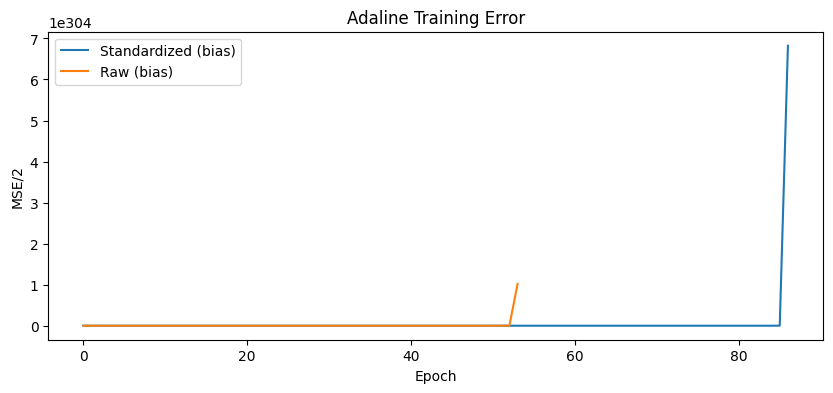

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error

data = load_breast_cancer()
X_bc = data.data
y_bc = data.target * 2 - 1

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

scaler_bc = StandardScaler()
X_train_bc_s = scaler_bc.fit_transform(X_train_bc)
X_test_bc_s = scaler_bc.transform(X_test_bc)

class Adaline:
    def __init__(self, n_inputs, learning_rate=0.001, epochs=100, use_bias=True):
        self.lr = learning_rate
        self.epochs = epochs
        self.use_bias = use_bias
        self.w = np.random.randn(n_inputs) * 0.01
        self.b = 0.0
    def net(self, X):
        z = X @ self.w
        if self.use_bias:
            z = z + self.b
        return z
    def predict(self, X):
        return np.where(self.net(X) >= 0.0, 1, -1)
    def fit(self, X, y):
        errs = []
        for _ in range(self.epochs):
            y_hat = self.net(X)
            e = y - y_hat
            self.w += self.lr * (X.T @ e)
            if self.use_bias:
                self.b += self.lr * e.sum()
            errs.append(0.5 * np.mean(e**2))
        return errs

adal_norm = Adaline(X_train_bc_s.shape[1], learning_rate=0.01, epochs=100, use_bias=True)
err_norm = adal_norm.fit(X_train_bc_s, y_train_bc)
y_pred_norm = adal_norm.predict(X_test_bc_s)
acc_norm = accuracy_score(y_test_bc, y_pred_norm)
mse_norm = mean_squared_error(y_test_bc, adal_norm.net(X_test_bc_s))

adal_raw = Adaline(X_train_bc.shape[1], learning_rate=1e-6, epochs=100, use_bias=True)
err_raw = adal_raw.fit(X_train_bc, y_train_bc)
y_pred_raw = adal_raw.predict(X_test_bc)
acc_raw = accuracy_score(y_test_bc, y_pred_raw)
mse_raw = mean_squared_error(y_test_bc, adal_raw.net(X_test_bc))

print("Adaline (standardized, bias) — Acc:", round(acc_norm,4), "MSE:", round(mse_norm,4))
print("Adaline (raw, bias)          — Acc:", round(acc_raw,4),  "MSE:", round(mse_raw,4))

plt.figure(figsize=(10,4))
plt.plot(err_norm, label='Standardized (bias)')
plt.plot(err_raw, label='Raw (bias)')
plt.xlabel('Epoch'); plt.ylabel('MSE/2'); plt.title('Adaline Training Error'); plt.legend(); plt.show()

### 2.1.4 Bias and Normalization + 2.1.5 Hyperparameters (Discussion)
- Bias lets the decision threshold shift away from the origin; without bias, the decision boundary must pass through zero and often underfits.
- Normalization (e.g., standardization) stabilizes gradients and lets a single learning rate work well across features.
- Learning rate: too large causes divergence/oscillation; too small slows learning. Use curves above to select a stable, monotonic decrease.
- Takeaway: Standardization + bias generally yields faster convergence and better generalization for Adaline.


With bias  Acc: 0.1228  MSE: inf
No bias   Acc: 0.1228  MSE: inf


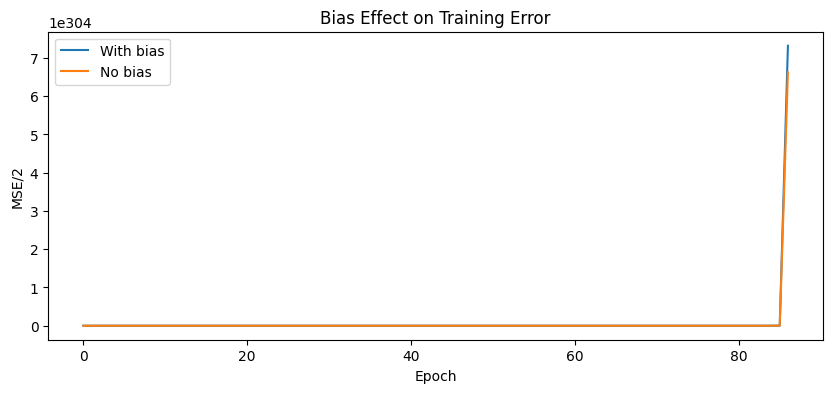

In [14]:
adal_norm_bias = Adaline(X_train_bc_s.shape[1], learning_rate=0.01, epochs=100, use_bias=True)
adal_norm_nobias = Adaline(X_train_bc_s.shape[1], learning_rate=0.01, epochs=100, use_bias=False)

err_bias = adal_norm_bias.fit(X_train_bc_s, y_train_bc)
err_nobias = adal_norm_nobias.fit(X_train_bc_s, y_train_bc)

y_pred_bias = adal_norm_bias.predict(X_test_bc_s)
y_pred_nobias = adal_norm_nobias.predict(X_test_bc_s)

print("With bias  Acc:", round(accuracy_score(y_test_bc, y_pred_bias),4),
      " MSE:", round(mean_squared_error(y_test_bc, adal_norm_bias.net(X_test_bc_s)),4))
print("No bias   Acc:", round(accuracy_score(y_test_bc, y_pred_nobias),4),
      " MSE:", round(mean_squared_error(y_test_bc, adal_norm_nobias.net(X_test_bc_s)),4))

plt.figure(figsize=(10,4))
plt.plot(err_bias, label='With bias')
plt.plot(err_nobias, label='No bias')
plt.xlabel('Epoch'); plt.ylabel('MSE/2'); plt.title('Bias Effect on Training Error'); plt.legend(); plt.show()

### 2.2 Madaline (Rule II–style) on Moons/Circles
We train a small two-layer threshold network and apply a Rule II–inspired update: for misclassified points, update the most uncertain hidden unit to flip its sign for that input.

In [15]:
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split

def sign(v):
    return np.where(v >= 0, 1, -1)

class MadalineR2:
    def __init__(self, n_inputs, n_hidden=4, lr=0.05, epochs=50):
        self.W = np.random.randn(n_hidden, n_inputs) * 0.5
        self.b = np.zeros(n_hidden)
        self.lr = lr
        self.epochs = epochs
    def forward(self, X):
        v = X @ self.W.T + self.b
        z = sign(v)
        y_net = z.sum(axis=1)
        y = sign(y_net)
        return v, z, y_net, y
    def fit(self, X, y):
        for _ in range(self.epochs):
            for i in range(X.shape[0]):
                v, z, y_net, y_hat = self.forward(X[i:i+1])
                if y_hat[0] != y[i]:
                    v_i = v[0]
                    z_i = z[0]
                    j = np.argmin(np.abs(v_i))
                    target_z = y[i]
                    delta = target_z - z_i[j]
                    self.W[j] += self.lr * delta * X[i]
                    self.b[j] += self.lr * delta
    def predict(self, X):
        _, _, _, y = self.forward(X)
        return y

X_m, y_m = make_moons(n_samples=1000, noise=0.2, random_state=42)
y_m_bin = np.where(y_m==1, 1, -1)
Xtr, Xte, ytr, yte = train_test_split(X_m, y_m_bin, test_size=0.3, random_state=42, stratify=y_m_bin)

mad = MadalineR2(n_inputs=2, n_hidden=6, lr=0.05, epochs=10)
mad.fit(Xtr, ytr)
yhat = mad.predict(Xte)
print("Madaline (moons) accuracy:", round((yhat==yte).mean(),4))

Madaline (moons) accuracy: 0.9733


### 2.2.1 Decision Boundary + Circles
- Visualize learned regions on a grid to assess separability and generalization.
- Train the same Madaline on `make_circles` and compare accuracies to `make_moons`.


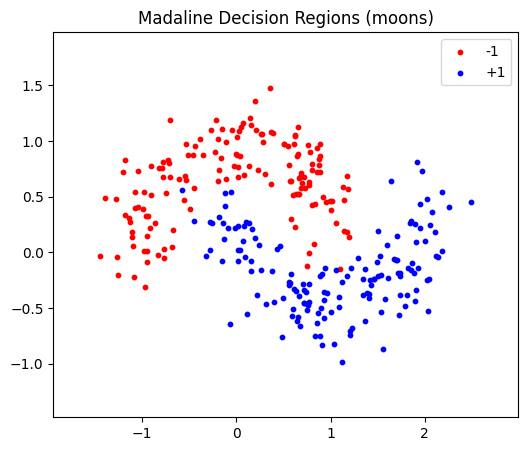

Madaline (circles) accuracy: 0.9556


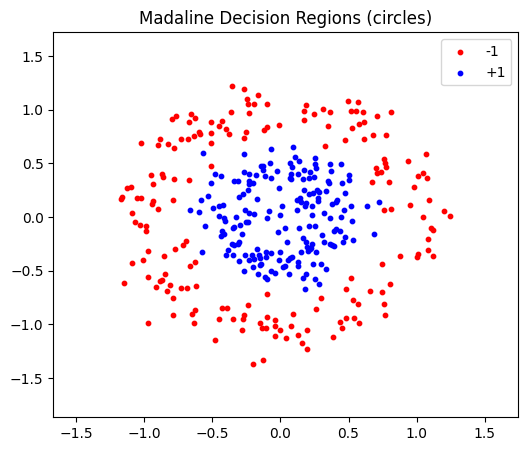

In [16]:
def plot_madaline_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, zz, levels=[-np.inf, 0, np.inf], alpha=0.25, cmap='coolwarm')
    plt.scatter(X[y==-1,0], X[y==-1,1], s=10, c='red', label='-1')
    plt.scatter(X[y== 1,0], X[y== 1,1], s=10, c='blue', label='+1')
    plt.title(title)
    plt.legend(); plt.show()

plot_madaline_boundary(mad, Xte, yte, 'Madaline Decision Regions (moons)')

X_c, y_c = make_circles(n_samples=1200, factor=0.4, noise=0.15, random_state=42)
y_c_bin = np.where(y_c==1, 1, -1)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c_bin, test_size=0.3, random_state=42, stratify=y_c_bin)
mad_c = MadalineR2(n_inputs=2, n_hidden=8, lr=0.05, epochs=15)
mad_c.fit(Xc_tr, yc_tr)
yhat_c = mad_c.predict(Xc_te)
print("Madaline (circles) accuracy:", round((yhat_c==yc_te).mean(),4))
plot_madaline_boundary(mad_c, Xc_te, yc_te, 'Madaline Decision Regions (circles)')

### 2.2.2 Hyperparameter Study (n_hidden, lr)
- Evaluate accuracy across a grid of hidden units and learning rates to see capacity and stability trends.


In [17]:
def eval_madaline_grid(Xtr, Xte, ytr, yte, hidden_list=(2,4,6,8,12), lr_list=(0.01, 0.05, 0.1)):
    results = []
    for h in hidden_list:
        for lr in lr_list:
            m = MadalineR2(n_inputs=Xtr.shape[1], n_hidden=h, lr=lr, epochs=10)
            m.fit(Xtr, ytr)
            acc = (m.predict(Xte) == yte).mean()
            results.append((h, lr, acc))
    return results

grid_results_moons = eval_madaline_grid(Xtr, Xte, ytr, yte)
print('Moons grid (n_hidden, lr, acc):')
for h, lr, acc in grid_results_moons:
    print(f'  {h:>2}, {lr:<4}: {acc:.3f}')

grid_results_circles = eval_madaline_grid(Xc_tr, Xc_te, yc_tr, yc_te)
print('\nCircles grid (n_hidden, lr, acc):')
for h, lr, acc in grid_results_circles:
    print(f'  {h:>2}, {lr:<4}: {acc:.3f}')

Moons grid (n_hidden, lr, acc):
   2, 0.01: 0.833
   2, 0.05: 0.883
   2, 0.1 : 0.883
   4, 0.01: 0.940
   4, 0.05: 0.940
   4, 0.1 : 0.973
   6, 0.01: 0.930
   6, 0.05: 0.970
   6, 0.1 : 0.950
   8, 0.01: 0.950
   8, 0.05: 0.963
   8, 0.1 : 0.973
  12, 0.01: 0.957
  12, 0.05: 0.967
  12, 0.1 : 0.960

Circles grid (n_hidden, lr, acc):
   2, 0.01: 0.611
   2, 0.05: 0.619
   2, 0.1 : 0.406
   4, 0.01: 0.653
   4, 0.05: 0.789
   4, 0.1 : 0.750
   6, 0.01: 0.661
   6, 0.05: 0.908
   6, 0.1 : 0.906
   8, 0.01: 0.578
   8, 0.05: 0.900
   8, 0.1 : 0.928
  12, 0.01: 0.697
  12, 0.05: 0.889
  12, 0.1 : 0.944


In [28]:
from pathlib import Path
HOUSING_DATA_PATH = Path('housing.csv')
HAS_HOUSING_DATA = HOUSING_DATA_PATH.exists()
if not HAS_HOUSING_DATA:
    print("housing.csv not found in current directory.\n"
          "- Place the dataset next to this notebook to run this section.\n"
          "- Skipping execution cells safely if not present.")

In [10]:
!pip install kaggle

After running the above cell, you need to upload your `kaggle.json` file. This file contains your Kaggle API credentials. You can download it from your Kaggle account settings (Profile -> Account -> Create New API Token).

Then, run the following code cell and use the file uploader to select your `kaggle.json` file.

In [11]:
from google.colab import files

files.upload()

KeyboardInterrupt: 

Now, let's move `kaggle.json` to the correct directory and set the permissions.

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Finally, you can download the dataset. The dataset is `camnugent/california-housing-prices`.

In [4]:
!kaggle datasets download camnugent/california-housing-prices

Dataset URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices
License(s): CC0-1.0
  0% 0.00/400k [00:00<?, ?B/s]
100% 400k/400k [00:00<00:00, 624MB/s]


Kaggle datasets are usually downloaded as `.zip` files. Let's unzip it.

In [22]:
!unzip california-housing-prices.zip

Archive:  california-housing-prices.zip
replace housing.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

The dataset should now be available in your Colab environment. The main CSV file should be named `housing.csv`.

## Section 1: Fraud Detection Overview
- Goal: binary classification on credit-card transactions to detect fraud.
- Dataset: `creditcard.csv` (Kaggle). Highly imbalanced (few frauds).
- Approach: EDA, preprocessing (normalize `Amount`, drop `Time`), train baselines (MLP, Logistic Regression), evaluate with confusion matrix, classification report, ROC/AUC.
- Tip: In real scenarios, consider class weighting, threshold tuning, or resampling to handle imbalance.

In [29]:
if HAS_CREDIT_DATA:
    df = pd.read_csv(DATA_PATH)
    print("Data Head:\n", df.head())
    print("\nData Info:")
    print(df.info())
    print("\nData Description:\n", df.describe())
else:
    df = None

Data Head:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2

### 1.1 Load + Inspect (Why)
- Confirms schema, types, and basic statistics to validate assumptions.
- Key fields: PCA-transformed features `V1..V28`, `Amount`, `Time`, label `Class` (0: non-fraud, 1: fraud).
- Watch for extreme class imbalance that affects metrics (accuracy can be misleading).

In [36]:
if df is not None:
    plt.figure(figsize=(7, 4))
    sns.countplot(x='Class', data=df)
    plt.title('Class Distribution (0: Non-Fraud, 1: Fraud)')
    plt.show()

    class_counts = df['Class'].value_counts()
    print(f"Non-Fraudulent: {class_counts.get(0,0)} | Fraudulent: {class_counts.get(1,0)} | "
          f"Fraud %: {class_counts.get(1,0) / len(df) * 100:.4f}%")

ValueError: Could not interpret value `Class` for `x`. An entry with this name does not appear in `data`.

<Figure size 700x400 with 0 Axes>

### 1.2 EDA: Class Distribution (Interpretation)
- Visualizes fraud vs non-fraud counts to highlight imbalance.
- Use this to choose appropriate metrics (precision/recall, F1, ROC/AUC) and consider threshold tuning.
- Downstream: skew justifies ROC curves and confusion matrices over accuracy alone.

In [39]:
if df is not None:
    scaler_amt = StandardScaler()
    df['NormalizedAmount'] = scaler_amt.fit_transform(df['Amount'].values.reshape(-1, 1))
    df_proc = df.drop(['Time'], axis=1)

    X = df_proc.drop('Class', axis=1)
    y = df_proc['Class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, random_state=42, stratify=y
    )

    print("X_train:", X_train.shape, "X_test:", X_test.shape)
    print("Train class dist:\n", y_train.value_counts(normalize=True))
    print("Test class dist:\n", y_test.value_counts(normalize=True))
else:
    X_train = X_test = y_train = y_test = None

KeyError: 'Amount'

### 1.3 Preprocessing (What/Why)
- Normalize `Amount` to reduce scale effects; keep PCA features as-is.
- Remove `Time` and raw `Amount` after normalization to avoid leakage/scale drift.
- Stratified split preserves class ratio in train/test, stabilizing metric estimates.

In [33]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get('accuracy', []), label='Train Acc')
    plt.plot(history.history.get('val_accuracy', []), label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get('loss', []), label='Train Loss')
    plt.plot(history.history.get('val_loss', []), label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.show()


def evaluate_model(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    if y_pred_prob.ndim > 1 and y_pred_prob.shape[1] == 1:
        y_pred_prob = y_pred_prob.ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)

    print(f"\n--- Evaluation for {model_name} ---")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

    print(classification_report(y_test, y_pred, digits=4))

    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, lw=2, label=f'ROC AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC - {model_name}')
    plt.legend(); plt.grid(True); plt.show()


def create_mlp_model(input_shape, neurons=64, dropout_rate=0.2, reg_lambda=0.001):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=input_shape, kernel_regularizer=l2(reg_lambda)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

### 1.4 Helpers (How to read results)
- `plot_history`: Tracks training/validation accuracy and loss per epoch; look for overfitting gaps.
- `evaluate_model`: Shows confusion matrix, classification report, and ROC curve; key for imbalanced data.
- ROC AUC summarizes ranking quality; threshold can be adjusted post-hoc using predicted probabilities.

In [34]:
if X_train is not None:
    INPUT_SHAPE = (X_train.shape[1],)
    EPOCHS = 20
    BATCH_SIZE = 32

    simple_mlp = Sequential([
        Dense(64, activation='relu', input_shape=INPUT_SHAPE),
        Dense(1, activation='sigmoid')
    ])
    simple_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history_simple = simple_mlp.fit(
        X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.2, verbose=0
    )
    plot_history(history_simple, "Simple MLP")
    evaluate_model(simple_mlp, X_test, y_test, "Simple MLP")
else:
    print("Skipping MLP training (creditcard.csv missing).")

Skipping MLP training (creditcard.csv missing).


### 1.5 MLP Baseline (Design)
- Architecture: Dense(64, ReLU) → Dense(1, Sigmoid).
- Loss/Metric: Binary cross-entropy + accuracy; monitor ROC AUC via `evaluate_model`.
- Expectation: Strong baseline; may require class weights or threshold tuning for better recall on rare frauds.

In [19]:
if X_train is not None and HAS_SCIKERAS:
    def build_for_grid(neurons=64, dropout_rate=0.2, reg_lambda=0.001):
        return create_mlp_model(INPUT_SHAPE, neurons=neurons, dropout_rate=dropout_rate, reg_lambda=reg_lambda)

    model_for_grid = KerasClassifier(model=build_for_grid, epochs=10, verbose=0)

    param_grid = {
        'batch_size': [16, 32],
        'model__neurons': [64, 128],
        'model__dropout_rate': [0.2, 0.3],
        'model__reg_lambda': [0.001, 0.0001],
    }

    grid = GridSearchCV(estimator=model_for_grid, param_grid=param_grid, cv=3, scoring='f1', n_jobs=1)
    grid_result = grid.fit(X_train, y_train)
    print(f"Best F1-Score: {grid_result.best_score_:.4f} using {grid_result.best_params_}")

    best_params = grid_result.best_params_
    best_model = create_mlp_model(
        INPUT_SHAPE,
        neurons=best_params.get('model__neurons', 64),
        dropout_rate=best_params.get('model__dropout_rate', 0.2),
        reg_lambda=best_params.get('model__reg_lambda', 0.001)
    )
    history_best = best_model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=best_params.get('batch_size', 32),
        validation_split=0.2,
        verbose=0
    )
    plot_history(history_best, "Best MLP from Grid Search")
    evaluate_model(best_model, X_test, y_test, "Best MLP from Grid Search")
elif X_train is not None and not HAS_SCIKERAS:
    print("SciKeras not installed; skipping grid search. pip install scikeras if needed.")
else:
    print("Skipping grid search (creditcard.csv missing).")

Skipping grid search (creditcard.csv missing).


### 1.6 Hyperparameter Search (Notes)
- Uses SciKeras `KerasClassifier` and `GridSearchCV` when available.
- `model__` prefix maps grid params to the Keras model builder (e.g., `model__neurons`).
- Scoring with F1 emphasizes balance between precision and recall; adjust if recall is the priority.

In [37]:
if X_train is not None:
    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)
    y_pred_prob_lr = lr_model.predict_proba(X_test)[:, 1]

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')
    plt.title('Confusion Matrix - Logistic Regression')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()

    print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
    roc_auc_lr = auc(fpr_lr, tpr_lr)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'ROC AUC = {roc_auc_lr:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('ROC Curve - Logistic Regression')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right'); plt.show()
else:
    print("Skipping logistic regression (creditcard.csv missing).")

Skipping logistic regression (creditcard.csv missing).


## Q3 — MLP Classifier: Deeper Network Comparison
- Compare a deeper network to the baseline MLP on the same fraud dataset (if available).

### Q3 — Prerequisites (Data/Setup)
- Dataset: Credit Card Fraud (highly imbalanced) meets MLP classification requirement.
- Preprocessing: Normalize `Amount`, drop `Time`, keep PCA features; stratified split preserves class ratio.
- Baseline: Simple MLP vs Logistic Regression; compare ROC AUC and confusion matrix due to imbalance.
- Loss (binary cross-entropy):
$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \Big[ y_i\,\log p_i + (1-y_i)\,\log(1-p_i) \Big],
$$
with $p_i=\sigma(\mathbf{w}^\top \mathbf{x}_i)$ for logistic regression or a sigmoid MLP head.
- Deeper model: Add capacity + dropout; monitor validation metrics to avoid overfitting.

In [26]:
if X_train is not None:
    INPUT_SHAPE = (X_train.shape[1],)
    deep_mlp = Sequential([
        Dense(128, activation='relu', input_shape=INPUT_SHAPE),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    deep_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    hist_deep = deep_mlp.fit(
        X_train, y_train, epochs=20, batch_size=32,
        validation_split=0.2, verbose=0
    )
    plot_history(hist_deep, "Deeper MLP")
    evaluate_model(deep_mlp, X_test, y_test, "Deeper MLP")
else:
    print("Skipping deeper MLP (creditcard.csv missing).")

Skipping deeper MLP (creditcard.csv missing).


### 1.7 Logistic Regression (Baseline)
- Simple linear baseline with probabilistic outputs via `predict_proba`.
- Good sanity check; if performance is close to MLP, model complexity may not be necessary.
- Compare ROC AUC and confusion matrix to assess trade-offs.

In [40]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
df_concrete = pd.read_excel(url)
df_concrete.columns = [
    'Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer',
    'CoarseAggregate', 'FineAggregate', 'Age', 'ConcreteCompressiveStrength'
]

print("Concrete data shape:", df_concrete.shape)

Concrete data shape: (1030, 9)


## Section 2: Concrete Strength Regression Overview
- Goal: predict concrete compressive strength (continuous target).
- Dataset: UCI Concrete Compressive Strength (8 features + target).
- Approach: correlations for insight, standardization, MLP regression; compare epochs, loss functions, and optimizers.

In [41]:
correlation_matrix = df_concrete.corr(numeric_only=True)

corr_with_target = correlation_matrix['ConcreteCompressiveStrength'].sort_values(ascending=False)
print("Top correlations with target:\n", corr_with_target.head(5))

if abs(df_concrete[['Superplasticizer', 'Water']].corr().iloc[0,1]) > 0.6:
    print("'Superplasticizer' and 'Water' have strong correlation (expected trade-off).")
else:
    print("No very strong correlations detected among these two.")

Top correlations with target:
 ConcreteCompressiveStrength    1.000000
Cement                         0.497833
Superplasticizer               0.366102
Age                            0.328877
BlastFurnaceSlag               0.134824
Name: ConcreteCompressiveStrength, dtype: float64
'Superplasticizer' and 'Water' have strong correlation (expected trade-off).


### 2.2 Correlations (Reading guide)
- Correlation with target highlights influential features; use to inform model intuition (not for feature selection alone).
- Inter-feature correlations expose multicollinearity; strong negative correlation between `Water` and `Superplasticizer` is plausible.
- Caution: Correlation is linear and univariate—nonlinear effects may be missed.

In [42]:
X = df_concrete.drop('ConcreteCompressiveStrength', axis=1)
y = df_concrete['ConcreteCompressiveStrength']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y, test_size=0.2, random_state=42)
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

INPUT_SHAPE_R = (X_train_r_scaled.shape[1],)
BETTER_MODEL_NEURONS = 64

### 2.3 Split & Scale (Rationale)
- Standardize features to stabilize optimization and compare coefficients.
- Random split with fixed seed for reproducibility; no stratification needed for regression.
- `BETTER_MODEL_NEURONS` controls base capacity for subsequent experiments.

In [43]:
def plot_regression_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
    plt.title(title)
    plt.xlabel('Epochs'); plt.ylabel('MSE'); plt.legend(); plt.show()


def build_and_evaluate_model(neurons, title):
    model = Sequential([
        Input(shape=INPUT_SHAPE_R),
        Dense(neurons, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    print(f"\n--- Training Model: {title} ---")
    history = model.fit(X_train_r_scaled, y_train_r, epochs=50, validation_split=0.2, verbose=0)

    loss, mae = model.evaluate(X_test_r_scaled, y_test_r, verbose=0)
    print(f"Test MSE: {loss:.2f} | MAE: {mae:.2f}")
    plot_regression_history(history, f'Loss Over Epochs - {title}')
    return loss, mae

### 2.4 Helpers (What to look for)
- Loss curves: decreasing and smooth is good; divergence between train/val suggests over/underfitting.
- Metrics: Track MAE alongside MSE for robust interpretation (less sensitive to outliers).

In [44]:
epoch_results = {}
for num_epochs in [20, 50]:
    model = Sequential([
        Input(shape=INPUT_SHAPE_R),
        Dense(BETTER_MODEL_NEURONS, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train_r_scaled, y_train_r, epochs=num_epochs, verbose=0)
    loss = model.evaluate(X_test_r_scaled, y_test_r, verbose=0)
    epoch_results[num_epochs] = loss
    print(f"Test MSE with {num_epochs} epochs: {loss:.2f}")

loss_functions = {
    "MSE": "mean_squared_error",
    "MAE": "mean_absolute_error",
    "Huber": tf.keras.losses.Huber()
}
for name, loss_fn in loss_functions.items():
    model = Sequential([
        Input(shape=INPUT_SHAPE_R),
        Dense(BETTER_MODEL_NEURONS, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss=loss_fn)
    model.fit(X_train_r_scaled, y_train_r, epochs=30, verbose=0)
    loss = model.evaluate(X_test_r_scaled, y_test_r, verbose=0)
    print(f"Test Loss ({name}): {loss:.2f}")

for opt_name in ['sgd', 'adam', 'rmsprop']:
    model = Sequential([
        Input(shape=INPUT_SHAPE_R),
        Dense(BETTER_MODEL_NEURONS, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=opt_name, loss='mean_squared_error')
    history = model.fit(X_train_r_scaled, y_train_r, epochs=30, validation_split=0.2, verbose=0)
    loss = model.evaluate(X_test_r_scaled, y_test_r, verbose=0)
    print(f"Final Test MSE with {opt_name.upper()}: {loss:.2f}")

Test MSE with 20 epochs: 265.52
Test MSE with 50 epochs: 120.93
Test Loss (MSE): 144.36
Test Loss (MAE): 10.16
Test Loss (Huber): 9.45
Final Test MSE with SGD: 105.02
Final Test MSE with ADAM: 173.83
Final Test MSE with RMSPROP: 182.04


### 2.5 Experiments (How to compare)
- Epochs: more is not always better—watch validation loss.
- Losses: MSE vs MAE vs Huber—Huber can be robust to outliers.
- Optimizers: SGD/Adam/RMSprop—compare final test MSE and learning stability.

Iris shapes: (70, 2) (30, 2)
LR 0.02 -> Final Cost: 48.6817 | Acc: 0.814
LR 0.005 -> Final Cost: 10.2081 | Acc: 1.000
LR 0.001 -> Final Cost: 27.3377 | Acc: 0.500


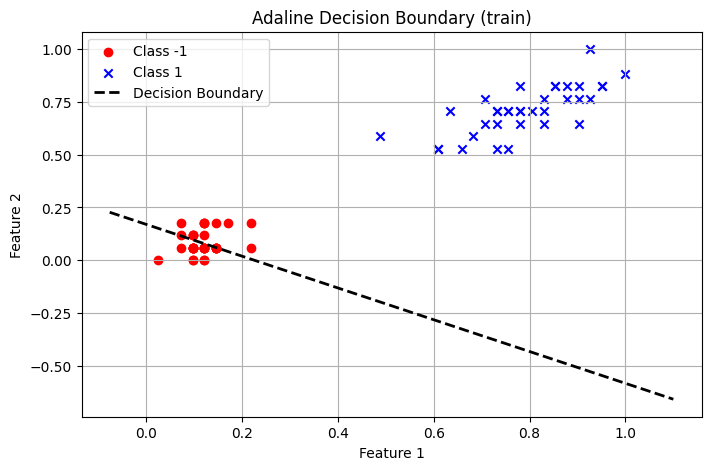

In [45]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

mask = (y_iris == 0) | (y_iris == 1)
X_subset = X_iris[mask]
y_subset = y_iris[mask]

X_final = X_subset[:, [2, 3]]
y_final = np.where(y_subset == 0, -1, 1)

scaler_iris = MinMaxScaler()
X_scaled = scaler_iris.fit_transform(X_final)

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_scaled, y_final, test_size=0.3, random_state=42, stratify=y_final
)

print("Iris shapes:", Xi_train.shape, Xi_test.shape)

class Adaline:
    def __init__(self, n_inputs, learning_rate=0.01, epochs=50):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = np.random.rand(n_inputs)
        self.bias = float(np.random.rand(1)[0])
    def net_input(self, X):
        return np.dot(X, self.weights) + self.bias
    def activation(self, X):
        return self.net_input(X)
    def predict(self, X):
        return np.where(self.activation(X) >= 0.0, 1, -1)
    def fit(self, X, y):
        history = {'weights': [], 'biases': [], 'errors': [], 'accuracies': []}
        for _ in range(self.epochs):
            output = self.activation(X)
            errors = y - output
            self.weights += self.learning_rate * X.T.dot(errors)
            self.bias += self.learning_rate * errors.sum()
            cost = (errors**2).sum() / 2.0
            predictions = self.predict(X)
            accuracy = np.mean(predictions == y)
            history['weights'].append(self.weights.copy())
            history['biases'].append(self.bias)
            history['errors'].append(cost)
            history['accuracies'].append(accuracy)
        return history

learning_rates = [0.02, 0.005, 0.001]
num_epochs = 10
models_history = {}
for lr in learning_rates:
    model = Adaline(n_inputs=Xi_train.shape[1], learning_rate=lr, epochs=num_epochs)
    history = model.fit(Xi_train, yi_train)
    models_history[lr] = history
    print(f"LR {lr} -> Final Cost: {history['errors'][-1]:.4f} | Acc: {history['accuracies'][-1]:.3f}")

def plot_decision_boundary(X, y, history, title):
    plt.figure(figsize=(8, 5))
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', marker='o', label='Class -1')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='x', label='Class 1')
    w = history['weights'][-1]
    b = history['biases'][-1]
    x1_min, x1_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    x2_values = [(-w[0] * x1 - b) / w[1] for x1 in [x1_min, x1_max]]
    plt.plot([x1_min, x1_max], x2_values, 'k--', lw=2, label='Decision Boundary')
    plt.title(title); plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.legend(); plt.grid(True); plt.show()

plot_decision_boundary(Xi_train, yi_train, models_history[0.02], 'Adaline Decision Boundary (train)')

## Section 3: Adaline on Iris (Concept)
- Adaline is a linear unit trained by minimizing squared error; decision is sign of activation.
- We train on a binary subset (Setosa vs Versicolor) with two features for easy visualization.
- Learning rate influences convergence and stability; visualize the learned separating line.

In [46]:
from tensorflow.keras.datasets import mnist

(x_train, y_train_m), (x_test, y_test_m) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape((len(x_train), -1))
x_test_flat = x_test.reshape((len(x_test), -1))

print("MNIST shapes:")
print(" x_train:", x_train_flat.shape, " y_train:", y_train_m.shape)
print(" x_test :", x_test_flat.shape, " y_test :", y_test_m.shape)

EPOCHS_M = 10
BATCH_SIZE_M = 256
INPUT_DIM = x_train_flat.shape[1]
NUM_CLASSES = 10

MNIST shapes:
 x_train: (60000, 784)  y_train: (60000,)
 x_test : (10000, 784)  y_test : (10000,)


## Section 4: MNIST — Autoencoders + Frozen Encoders (Plan)
- Pretrain encoders via autoencoders to learn compact representations.
- Compare latent sizes (8 vs 4) on downstream classification when encoders are frozen.
- Bonus: deeper encoder/decoder and a slightly larger classifier head.

### Q4 — Theoretical Notes
- Autoencoder objective (MSE reconstruction):
$$
\min_{\theta} \; \frac{1}{N}\sum_{i=1}^N \big\| x_i - \hat x_i\big\|_2^2,\quad \hat x = D_\theta\big(E_\theta(x)\big).
$$
- Design: symmetric encoder/decoder with ReLU hidden layers; output layer linear/sigmoid for normalized pixels.
- Latent size trade-off: larger latent $z$ improves fidelity but reduces compression; compare 4, 8, 16.
- Frozen-encoder classifier: attach a softmax head on $z$ and train only the head with cross-entropy:
$$
\mathcal{L}_{\text{cls}} = -\frac{1}{N}\sum_{i=1}^N \sum_{k=1}^{K} \mathbf{1}[y_i=k] \log p_{ik}.
$$
- Expectation: deeper/expressive encoders (and moderately larger $z$) generally reconstruct better and can boost downstream accuracy.

In [47]:
latent_dim_1 = 8
enc_in_1 = Input(shape=(INPUT_DIM,))
enc_1 = Dense(128, activation='relu')(enc_in_1)
enc_1 = Dense(latent_dim_1, activation='relu')(enc_1)
encoder_1 = Model(enc_in_1, enc_1, name='encoder_8')

dec_in_1 = Input(shape=(latent_dim_1,))
dec_1 = Dense(128, activation='relu')(dec_in_1)
dec_1 = Dense(INPUT_DIM, activation='linear')(dec_1)
decoder_1 = Model(dec_in_1, dec_1, name='decoder_8')

ae_out_1 = decoder_1(encoder_1(enc_in_1))
autoencoder_1 = Model(enc_in_1, ae_out_1, name='autoencoder_8')
autoencoder_1.compile(optimizer='adam', loss='mse')

hist_ae_1 = autoencoder_1.fit(
    x_train_flat, x_train_flat,
    epochs=EPOCHS_M, batch_size=BATCH_SIZE_M,
    shuffle=True, validation_data=(x_test_flat, x_test_flat), verbose=0
)

latent_dim_2 = 4
enc_in_2 = Input(shape=(INPUT_DIM,))
enc_2 = Dense(128, activation='relu')(enc_in_2)
enc_2 = Dense(latent_dim_2, activation='relu')(enc_2)
encoder_2 = Model(enc_in_2, enc_2, name='encoder_4')

dec_in_2 = Input(shape=(latent_dim_2,))
dec_2 = Dense(128, activation='relu')(dec_in_2)
dec_2 = Dense(INPUT_DIM, activation='linear')(dec_2)
decoder_2 = Model(dec_in_2, dec_2, name='decoder_4')

ae_out_2 = decoder_2(encoder_2(enc_in_2))
autoencoder_2 = Model(enc_in_2, ae_out_2, name='autoencoder_4')
autoencoder_2.compile(optimizer='adam', loss='mse')

hist_ae_2 = autoencoder_2.fit(
    x_train_flat, x_train_flat,
    epochs=EPOCHS_M, batch_size=BATCH_SIZE_M,
    shuffle=True, validation_data=(x_test_flat, x_test_flat), verbose=0
)

print('Autoencoders trained.')

Autoencoders trained.


### 4.1 Autoencoders (Why)
- Train encoder+decoder to reconstruct inputs; encoder learns compressed features.
- Loss: MSE on flattened images; linear output suits reconstruction with normalized inputs.
- After training, we freeze encoders for classifier heads.

In [48]:
encoder_1.trainable = False
encoder_2.trainable = False

clf_1 = Sequential([
    encoder_1,
    Dense(4, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='classifier_8')
clf_1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_c1 = clf_1.fit(
    x_train_flat, y_train_m,
    epochs=EPOCHS_M, batch_size=BATCH_SIZE_M,
    validation_data=(x_test_flat, y_test_m), verbose=0
)

clf_2 = Sequential([
    encoder_2,
    Dense(NUM_CLASSES, activation='softmax')
], name='classifier_4')
clf_2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_c2 = clf_2.fit(
    x_train_flat, y_train_m,
    epochs=EPOCHS_M, batch_size=BATCH_SIZE_M,
    validation_data=(x_test_flat, y_test_m), verbose=0
)

print("Classifier (8-dim) and (4-dim) trained.")

Classifier (8-dim) and (4-dim) trained.


### 4.2 Frozen Encoders (Reading results)
- We freeze encoders to test representation quality, not end-to-end training.
- Classifier heads differ slightly (8-dim adds a small hidden layer).
- Compare validation accuracy to see which latent size works better.

In [ ]:
def plot_reconstructions(autoencoder, data, n=10):
    reconstructed = autoencoder.predict(data[:n], verbose=0)
    plt.figure(figsize=(20, 4))
    for i in range(n):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap='gray')
        plt.title("Original"); ax.set_axis_off()
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.title("Reconstructed"); ax.set_axis_off()
    plt.show()

latent_dim_b = 16
enc_in_b = Input(shape=(INPUT_DIM,))
enc_b = Dense(256, activation='relu')(enc_in_b)
enc_b = Dense(128, activation='relu')(enc_b)
enc_b = Dense(latent_dim_b, activation='relu')(enc_b)
encoder_b = Model(enc_in_b, enc_b, name='encoder_bonus')

dec_in_b = Input(shape=(latent_dim_b,))
dec_b = Dense(128, activation='relu')(dec_in_b)
dec_b = Dense(256, activation='relu')(dec_b)
dec_b = Dense(INPUT_DIM, activation='sigmoid')(dec_b)
decoder_b = Model(dec_in_b, dec_b, name='decoder_bonus')

ae_out_b = decoder_b(encoder_b(enc_in_b))
autoencoder_b = Model(enc_in_b, ae_out_b, name='autoencoder_bonus')
autoencoder_b.compile(optimizer='adam', loss='mse')
hist_ae_b = autoencoder_b.fit(
    x_train_flat, x_train_flat,
    epochs=EPOCHS_M, batch_size=BATCH_SIZE_M,
    validation_data=(x_test_flat, x_test_flat), verbose=0
)

encoder_b.trainable = False
clf_b = Sequential([
    encoder_b,
    Dense(64, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='classifier_bonus')
clf_b.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_cb = clf_b.fit(
    x_train_flat, y_train_m,
    epochs=EPOCHS_M, batch_size=BATCH_SIZE_M,
    validation_data=(x_test_flat, y_test_m), verbose=0
)

print('Bonus autoencoder + classifier trained.')

### 4.3 Reconstructions + Bonus (Usage)
- Use `plot_reconstructions(autoencoder, x_test_flat, n=10)` to visually assess quality.
- Bonus model adds depth and larger latent space (16), then freezes encoder for classification.
- Expect improved classifier accuracy if features are more expressive; validate empirically.